<a href="https://colab.research.google.com/github/thanu-george/ML-algorithms/blob/main/LinearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [30]:
def load_and_preprocess(path, target_col):
    df = pd.read_csv(path)

    # Handle missing values
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            if df[col].dtype in ['float64', 'int64']:
                df[col] = df[col].fillna(df[col].mean())
            else:
                df[col] = df[col].fillna(df[col].mode()[0])

    # Encode categoricals
    for col in df.select_dtypes(include=['object']).columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))

    # Separate features and target
    X = df.drop(columns=[target_col])
    y = df[target_col]

    # 👉 SAVE original before scaling
    X_original = X.copy()

    # Scale
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42
    )

    # Also split original for plotting
    X_train_orig, X_test_orig, _, _ = train_test_split(
        X_original, y, test_size=0.2, random_state=42
    )

    return X_train, X_test, y_train, y_test, X_train_orig, X_test_orig

In [32]:
print("SIMPLE LINEAR REGRESSION")

path = input("Enter CSV path (default: data.csv): ").strip() or "data.csv"
target = input("Enter target column: ").strip()

X_train, X_test, y_train, y_test, X_train_orig, X_test_orig = load_and_preprocess(path, target)

# Select one feature for simple regression
print(f"Available features: {list(X_train.columns)}")
feat = input("Enter feature for simple regression: ").strip()
X_train_s = X_train[[feat]]
X_test_s = X_test[[feat]]

SIMPLE LINEAR REGRESSION
Enter CSV path (default: data.csv): /salary.csv
Enter target column: Salary


/tmp/ipykernel_4798/1379724969.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


Available features: ['YearsExperience']
Enter feature for simple regression: YearsExperience


In [33]:
# Train
model = LinearRegression()
model.fit(X_train_s, y_train)
print(f"Coefficient : {model.coef_[0]:.4f}")
print(f"Intercept   : {model.intercept_:.4f}")

# Predict
y_pred = model.predict(X_test_s)

# Evaluate — Regression Metrics
print(f"REGRESSION RESULTS")
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

Coefficient : 25100.3873
Intercept   : 75669.9896
REGRESSION RESULTS
MSE  : 43277377.3623
RMSE : 6578.5544


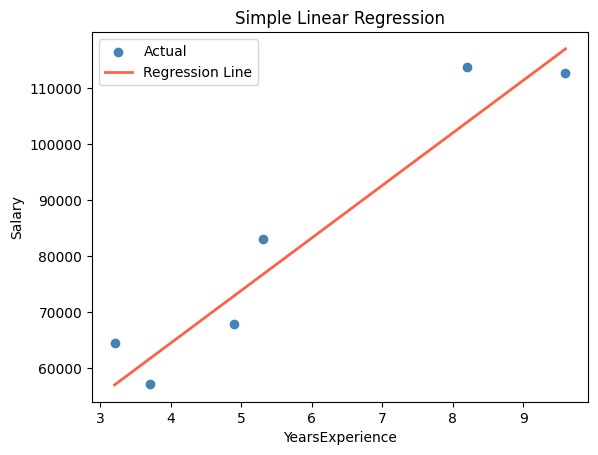

In [34]:
# Visualization — Regression Line Plot

x_vals = X_test_orig[feat].values  # NOT scaled

# sort for clean line
sorted_idx = x_vals.argsort()

plt.scatter(x_vals, y_test, color='steelblue', label='Actual')
plt.plot(x_vals[sorted_idx], y_pred[sorted_idx], color='tomato', linewidth=2, label='Regression Line')

plt.xlabel(feat)
plt.ylabel(target)
plt.title('Simple Linear Regression')
plt.legend()
plt.show()